# DLE602 Module 05: CNN Activity  
## Teaching Computers to See — Convolution, Filters and Pooling

This notebook is designed as an interactive activity for **Module 05: Convolutional Neural Networks (CNNs)**.

You will explore:

1. Why images are difficult for ordinary feedforward neural networks  
2. How convolution filters detect simple patterns  
3. How feature maps are created  
4. How max pooling reduces image size  
5. How these operations connect to a CNN pipeline  

**Learning goal:** By the end of this activity, you should be able to explain how a CNN starts from raw pixels and gradually extracts meaningful visual features.


## Activity 1: Why Feedforward Networks Struggle with Images

A small grayscale image of size **64 × 64** has:

\[
64 \times 64 = 4096
\]

input values.

A colour image has three channels: Red, Green and Blue.

\[
64 \times 64 \times 3 = 12288
\]

This means a fully connected neural network would need thousands of input neurons even for a small image.

Run the code below and change the image size to observe how quickly the number of inputs grows.


In [1]:
# Activity 1: Image size and number of input neurons

image_width = 64
image_height = 64
channels = 3   # use 1 for grayscale, 3 for RGB colour image

number_of_inputs = image_width * image_height * channels

print("Image size:", image_width, "x", image_height)
print("Channels:", channels)
print("Number of input neurons needed:", number_of_inputs)

# Try changing image_width and image_height to 128 or 256.


Image size: 64 x 64
Channels: 3
Number of input neurons needed: 12288


### Reflection

Answer briefly:

- What happens when the image size increases?
- Why might a fully connected network become expensive for images?
- Why do we need a smarter way to process image data?


## Activity 2: Create a Simple Image

Before working with real images, we will create a small artificial image using numbers.

In image processing:

- 0 can represent dark pixels  
- 1 can represent bright pixels  

The image below contains a simple vertical bright line. This allows us to test whether a filter can detect it.


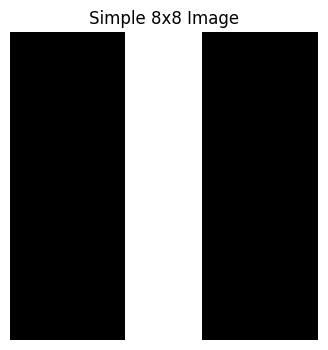

[[0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0.]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple 8x8 image
image = np.zeros((8, 8))
image[:, 3:5] = 1  # bright vertical bar

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Simple 8x8 Image")
plt.axis("off")
plt.show()

print(image)


## Activity 3: Apply a Convolution Filter

A **filter** or **kernel** is a small matrix that slides over an image.

At each location, the filter performs a dot product with the image patch.

Different filters detect different features, such as:

- vertical edges  
- horizontal edges  
- diagonal edges  
- brightness changes  

Run the code below to apply a vertical edge detection filter.


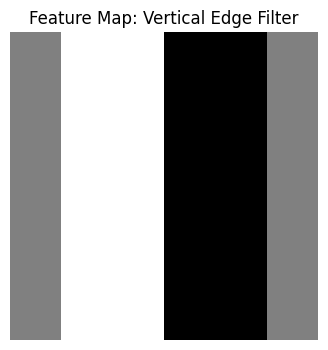

[[ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]]


In [3]:
def convolve2d(image, kernel, stride=1, padding=0):
    """Simple 2D convolution for teaching purposes."""
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode="constant", constant_values=0)

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for y in range(0, output_height):
        for x in range(0, output_width):
            patch = image[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
            output[y, x] = np.sum(patch * kernel)

    return output

# Vertical edge detector
vertical_edge_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

feature_map = convolve2d(image, vertical_edge_filter, stride=1, padding=0)

plt.figure(figsize=(4, 4))
plt.imshow(feature_map, cmap="gray")
plt.title("Feature Map: Vertical Edge Filter")
plt.axis("off")
plt.show()

print(feature_map)


### Try It Yourself

Change the filter below and observe the feature map.

Use these examples:

**Horizontal edge filter**

```python
[[-1, -1, -1],
 [ 0,  0,  0],
 [ 1,  1,  1]]
```

**Sharpening filter**

```python
[[ 0, -1,  0],
 [-1,  5, -1],
 [ 0, -1,  0]]
```

**Blur filter**

```python
[[1/9, 1/9, 1/9],
 [1/9, 1/9, 1/9],
 [1/9, 1/9, 1/9]]
```


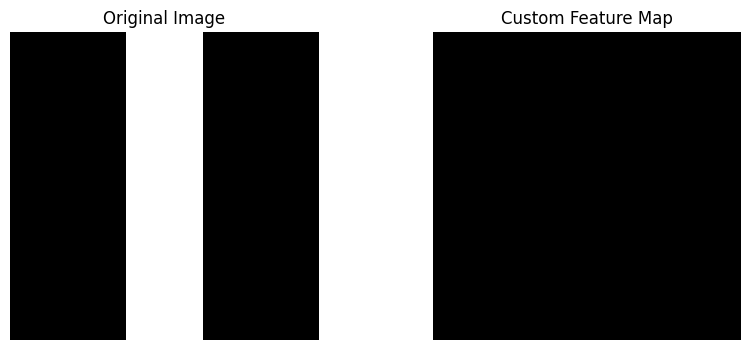

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [4]:
# Activity 3 extension: Change this filter and re-run the cell

custom_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

custom_feature_map = convolve2d(image, custom_filter, stride=1, padding=0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(custom_feature_map, cmap="gray")
plt.title("Custom Feature Map")
plt.axis("off")

plt.show()

print(custom_feature_map)


## Activity 4: Stride and Padding

Two important CNN parameters are:

### Stride
The number of pixels the filter moves each time.

- Stride = 1 means the filter moves one pixel at a time.
- Stride = 2 means the filter skips every second pixel.

### Padding
Adding extra pixels around the border of the image.

- Padding helps preserve image size.
- It allows the filter to process edge pixels.

Change `stride` and `padding` below and observe the output size.


Original image shape: (8, 8)
Feature map shape: (8, 8)


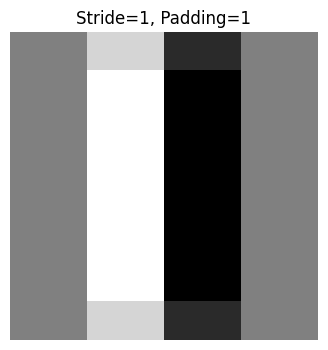

In [5]:
# Activity 4: Explore stride and padding

stride = 1
padding = 1

feature_map_stride_padding = convolve2d(image, vertical_edge_filter, stride=stride, padding=padding)

print("Original image shape:", image.shape)
print("Feature map shape:", feature_map_stride_padding.shape)

plt.figure(figsize=(4, 4))
plt.imshow(feature_map_stride_padding, cmap="gray")
plt.title(f"Stride={stride}, Padding={padding}")
plt.axis("off")
plt.show()


## Activity 5: Max Pooling

After convolution, CNNs often use **pooling**.

Pooling reduces the size of the feature map while keeping the most important information.

In **max pooling**, the largest value from each small region is kept.

This helps CNNs:

- reduce computation  
- reduce the number of parameters  
- focus on strongest features  
- become less sensitive to small shifts in the image  


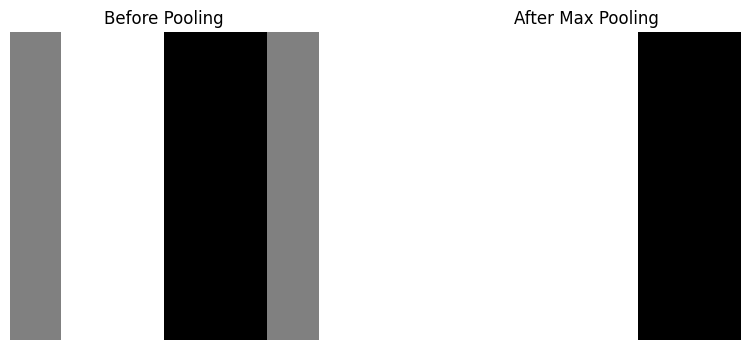

Feature map shape: (6, 6)
Pooled map shape: (3, 3)
[[3. 3. 0.]
 [3. 3. 0.]
 [3. 3. 0.]]


In [6]:
def max_pool2d(feature_map, pool_size=2, stride=2):
    """Simple max pooling for teaching purposes."""
    height, width = feature_map.shape

    output_height = (height - pool_size) // stride + 1
    output_width = (width - pool_size) // stride + 1

    pooled = np.zeros((output_height, output_width))

    for y in range(output_height):
        for x in range(output_width):
            patch = feature_map[y*stride:y*stride+pool_size, x*stride:x*stride+pool_size]
            pooled[y, x] = np.max(patch)

    return pooled

pooled_map = max_pool2d(feature_map, pool_size=2, stride=2)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(feature_map, cmap="gray")
plt.title("Before Pooling")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pooled_map, cmap="gray")
plt.title("After Max Pooling")
plt.axis("off")

plt.show()

print("Feature map shape:", feature_map.shape)
print("Pooled map shape:", pooled_map.shape)
print(pooled_map)


### Reflection

Answer briefly:

- What information is preserved after max pooling?
- What information is lost?
- Why might this still be useful for image recognition?


## Activity 6: Full Mini CNN Pipeline

Now we combine the key steps:

1. Input image  
2. Convolution  
3. Feature map  
4. ReLU activation  
5. Max pooling  
6. Flattening  

This is not a full trainable CNN, but it shows the core data flow.


Input image shape: (8, 8)
After convolution: (8, 8)
After ReLU: (8, 8)
After pooling: (4, 4)
After flattening: (16,)


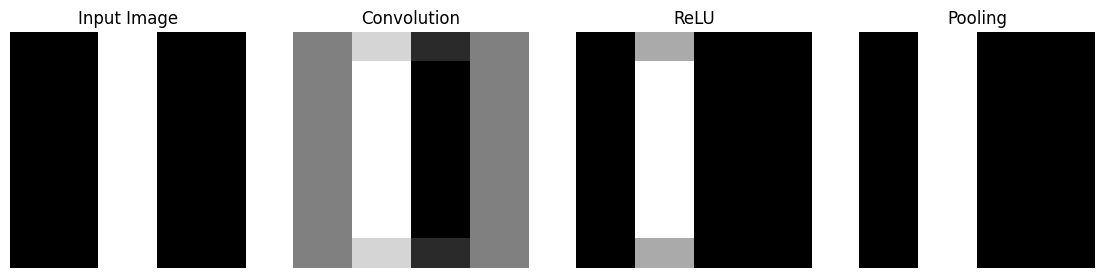

Flattened vector:
[0. 3. 0. 0. 0. 3. 0. 0. 0. 3. 0. 0. 0. 3. 0. 0.]


In [7]:
def relu(x):
    return np.maximum(0, x)

# Step 1: Input image
input_image = image

# Step 2: Convolution
conv_output = convolve2d(input_image, vertical_edge_filter, stride=1, padding=1)

# Step 3: ReLU
relu_output = relu(conv_output)

# Step 4: Max pooling
pool_output = max_pool2d(relu_output, pool_size=2, stride=2)

# Step 5: Flatten
flattened_output = pool_output.flatten()

print("Input image shape:", input_image.shape)
print("After convolution:", conv_output.shape)
print("After ReLU:", relu_output.shape)
print("After pooling:", pool_output.shape)
print("After flattening:", flattened_output.shape)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(conv_output, cmap="gray")
plt.title("Convolution")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(relu_output, cmap="gray")
plt.title("ReLU")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pool_output, cmap="gray")
plt.title("Pooling")
plt.axis("off")

plt.show()

print("Flattened vector:")
print(flattened_output)


## Activity 7: Use a Real Image

This section uses a sample image from `skimage`. If `skimage` is not installed in your environment, you can skip this section or install it.

The aim is to apply filters to a more realistic image and observe the feature maps.


In [8]:
try:
    from skimage import data, color
    from skimage.transform import resize

    real_image = data.camera()
    real_image = resize(real_image, (128, 128), anti_aliasing=True)

    filters = {
        "Vertical Edge": np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
        "Horizontal Edge": np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]),
        "Blur": np.ones((3, 3)) / 9,
        "Sharpen": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    }

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(real_image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    for i, (name, kernel) in enumerate(filters.items(), start=2):
        result = convolve2d(real_image, kernel, stride=1, padding=1)
        plt.subplot(2, 3, i)
        plt.imshow(result, cmap="gray")
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("This activity requires scikit-image.")
    print("You can install it using: pip install scikit-image")
    print("Error:", e)


This activity requires scikit-image.
You can install it using: pip install scikit-image
Error: No module named 'skimage'


## Optional Extension: Build a Simple CNN in Keras

This section is optional. It requires TensorFlow/Keras.

The purpose is to connect our manual convolution and pooling steps to a real CNN model.

You do not need to understand every line of code. Focus on the architecture:

- Conv2D  
- MaxPooling2D  
- Flatten  
- Dense  
- Output layer  


In [9]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.summary()

except Exception as e:
    print("TensorFlow is not available in this environment.")
    print("This optional section can be run in Google Colab.")
    print("Error:", e)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 8)         80        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 8)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 16)        1168      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 16)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 32)                1

## Final Reflection

Write short answers:

1. What does a convolution filter do?
2. Why are feature maps useful?
3. What is the purpose of pooling?
4. Why are CNNs more suitable than fully connected networks for image data?
5. How could CNNs be used in your Assessment 2 or Assessment 3 project?

### One-sentence takeaway

Complete this sentence:

> A CNN helps a computer recognise images by ...


## Teaching Notes for Instructor

Suggested classroom flow:

1. Start with Activity 1 to show the problem with fully connected networks.  
2. Use Activity 2 and Activity 3 to demonstrate convolution manually.  
3. Ask students to change the filter and explain what changed.  
4. Use Activity 4 to explore stride and padding.  
5. Use Activity 5 to show why pooling is useful.  
6. Use Activity 6 as the complete CNN pipeline summary.  
7. Use Activity 7 only if time permits.  
8. Use the Keras section as a bridge to future coding activities or assessment preparation.  

Recommended discussion prompts:

- Why is a CNN more efficient than a fully connected network for images?
- What kinds of features might early CNN layers detect?
- What kinds of features might deeper CNN layers detect?
- What could go wrong if CNNs are used in facial recognition, medical imaging or policing?
